In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [3]:
%matplotlib inline

# Import data

In [4]:
bands = [4, 5, 6, 7]


# all_bands    = ["Band 4 nterms2",  "Band 5 robust -1",     "Band 6", "Band 7 nterms2"]
# bands_naming = ['Band4_nterms2',   "Band5_robust_minus1",  'Band6',  'Band7_nterms2']
bands_labels = ['Band 4 test',          "Band 5",      'Band 6', 'Band 7']

# band_to_index = {band: i for i, band in enumerate(all_bands)}

wavelengths = [lambda_mm[band] for band in bands]
lambda_bands_cm = mm_to_cm(wavelengths)
# print(lambda_bands_cm)

# colours = [alma_band_colors[band] for band in bands]

In [5]:
f_values = [1, 0.5, 0.3, 0.1]

colours = [alma_band_colors[band] for band in bands]


prefix = "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/ZHANG_CODE/MY_npz_files/"

band_prefix = {
    4: 'BAND4/',
    5: 'BAND5/',
    6: 'BAND6/',
    7: 'BAND7/',
}


file_names = {
    '1'   : "dsharp_results_ff_1.00_smoothed_extrapol.npz",
    '0.75': "dsharp_results_ff_0.75_smoothed_extrapol.npz",
    '0.5': "dsharp_results_ff_0.50_smoothed_extrapol.npz",    
    '0.3': "dsharp_results_ff_0.30_smoothed_extrapol.npz",    
    '0.25': "dsharp_results_ff_0.25_smoothed_extrapol.npz",  
    '0.1': "dsharp_results_ff_0.10_smoothed_extrapol.npz"   
}


# Make an array to store the data
data = {}




for band, wav in zip(bands, wavelengths):
    data[wav] = {}

    for f in f_values:
        filename = prefix + band_prefix[band] + file_names[str(f)]
        d = np.load(filename)
        
        data[wav][str(f)] = do_things(d)

/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 1.2e+03%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 1e+03%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 8.5e+02%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 1.5e+03%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 2.8e+03%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 2e+03%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116

# Figure 5.4:

In [90]:
def plot_P_omega_grid(data, wavelengths, porosity_left='1', porosity_right = '0.5', albedo = 'w'):

    fig, axes = plt.subplots(4, 2, figsize=(18, 18), sharex=True, sharey=True)
    axes = axes.flatten()

    ax2_list = []
    
    if albedo == 'w':
        Pw_plot = 'P_omega'
        Pw_label = r'$P\omega$'
        
        w_plot = 'omega'
        w_label = r"$\omega$"
        
    elif albedo == 'w_eff':
        Pw_plot = 'P_omega_eff'
        Pw_label = r'$P\omega_{\mathrm{eff}}$'
        
        w_plot = 'omega_eff'
        w_label = r"$\omega_{\mathrm{eff}}$"
        
    else:
        return('albedo must equal w or w_eff')

    
    for j, ax in enumerate(axes):
        
        # Determine wavelength and column
        row = j // 2
        col = j % 2
        
        
        wavelength = wavelengths[row]

        # Choose porosity based on column
        if col == 0:
            porosity = porosity_left
        else:
            porosity = porosity_right
        
        
        band_data = data[wavelength][porosity]

        # Create twin axis
        ax2 = ax.twinx()
        ax2_list.append(ax2)

        # Plot P
        line_P, = ax.plot(cm_to_micron(band_data['a']), band_data['P'], color='red', label='$P$', lw=5)

        # Plot omega
        line_omega, = ax2.plot(cm_to_micron(band_data['a']), band_data[w_plot], color='dodgerblue', label=r'$\omega_{\mathrm{eff}}$', lw=5)

        # Plot P
        line_Pomega, = ax.plot(cm_to_micron(band_data['a']), band_data[Pw_plot],
                               color='black', label= Pw_label, lw=3,
                               ls = '--')
        
        # Log x-axis
        ax.set_xscale('log')
        add_min_major_ticks(ax)
        add_min_major_ticks(ax2)

        # Characteristic grain size
        a_char_micron = cm_to_micron(lambda_bands_cm[row] / (2 * np.pi))
        char_line = ax.axvline(a_char_micron, color='black', alpha=0.2, lw=5, label=r'$a_{\mathrm{char}} = \lambda / 2\pi$')

        # Limits
        ax.set_ylim(-0.1, 1.1)
        ax2.set_ylim(-0.1, 1.1)
        ax.set_xlim(1, max(cm_to_micron(band_data['a'])))

        # Title
        ax.text(0.05, 0.75, f"{wavelength} mm", transform=ax.transAxes, fontsize=25)

        # Ticks
        for a in [ax, ax2]:
            a.minorticks_on()
            a.tick_params(axis="x", which="minor", direction="in", length=4)
            a.tick_params(axis="y", which="minor", direction="in", length=4)
            a.tick_params(axis="x", which="major", direction="in", length=7, labelsize=axis_num_fs)
            a.tick_params(axis="y", which="major", direction="in", length=7, labelsize=axis_num_fs)

        # Hide omega tick labels on left column
        if col == 0:
            ax2.tick_params(axis='y', which='both', labelright=False)

        # Legend
        if j == 0:
            ax.legend(handles=[line_P, line_omega, char_line], fontsize=20, loc='center left', frameon=False)

        ax2.set_zorder(0)
        ax.set_zorder(1)
        
        
        # Make both backgrounds transparent
        ax.patch.set_visible(False)
        ax2.patch.set_visible(False)
    
    axes[0].text(0.5, 1.05, rf'$f = {porosity_left}$', transform=axes[0].transAxes, fontsize=30, ha='center')
    axes[1].text(0.5, 1.05, rf'$f = {porosity_right}$', transform=axes[1].transAxes, fontsize=30, ha='center')
    # Shared labels
    fig.supxlabel('Maximum grain size [$\mu$m]', fontsize=25, y=0.075)
    fig.supylabel(r"$P$", fontsize=25, x=0.025)

    # Horizontal omega label above right column
    fig.text(0.975, 0.5, w_label, fontsize=25, ha='center', va='center', rotation= 270,)

    # Spacing
    fig.subplots_adjust(wspace=0.1, hspace=0.1)

    return fig, axes

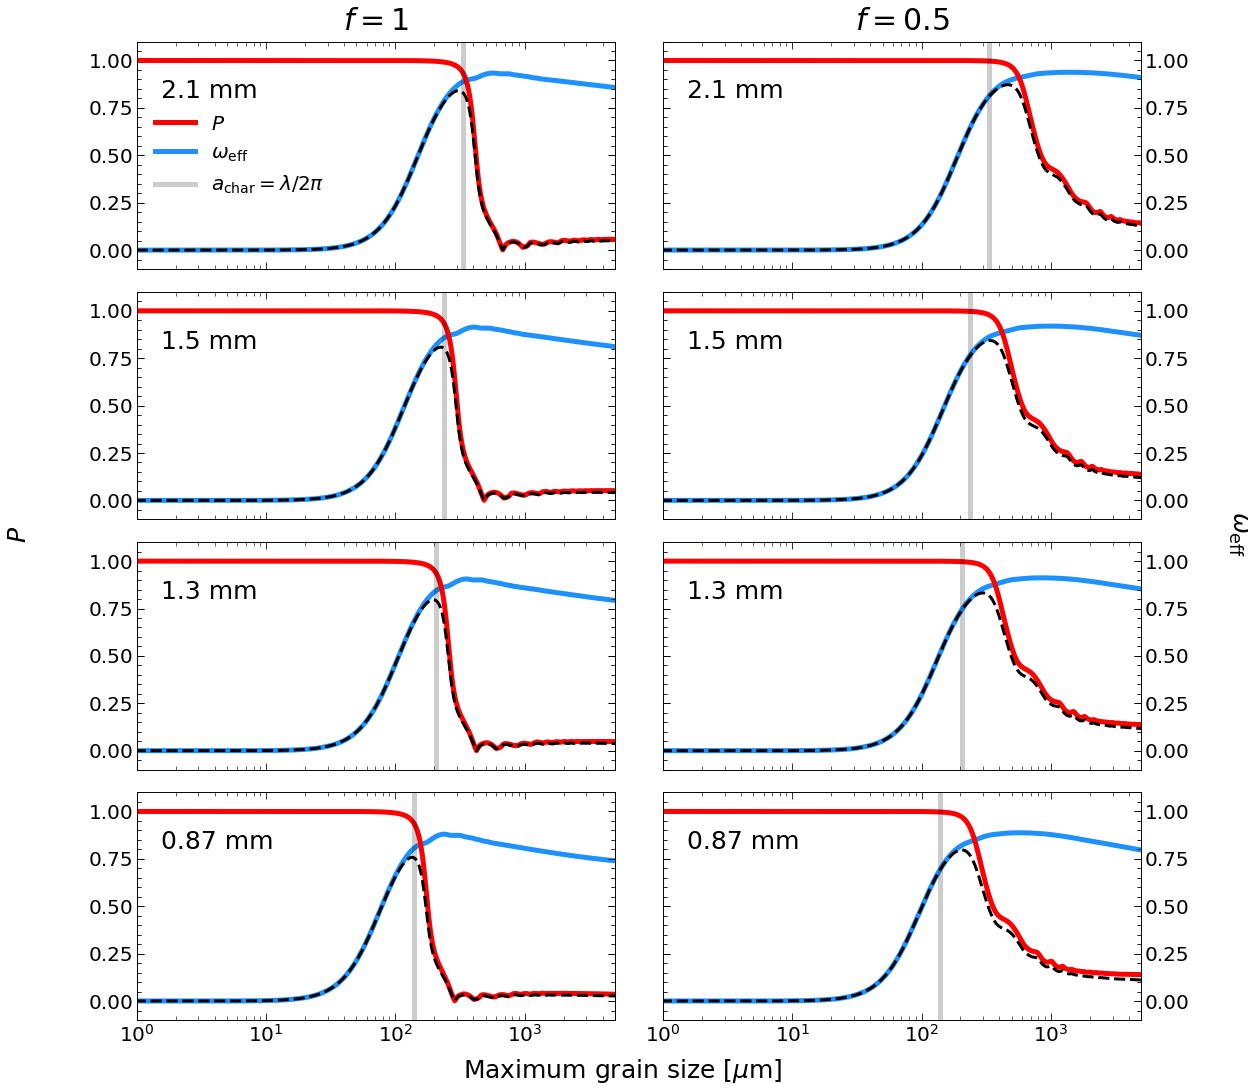

In [87]:
porosity = '1'
fig, axes = plot_P_omega_grid(data, wavelengths, albedo = 'w_eff')

plt.savefig(writeup_image_folder_path + '/DustModels/' + "P_vs_w_eff_vs_grainsize_grid_smooth_porosities.pdf",
            dpi=300, facecolor='white', bbox_inches='tight')

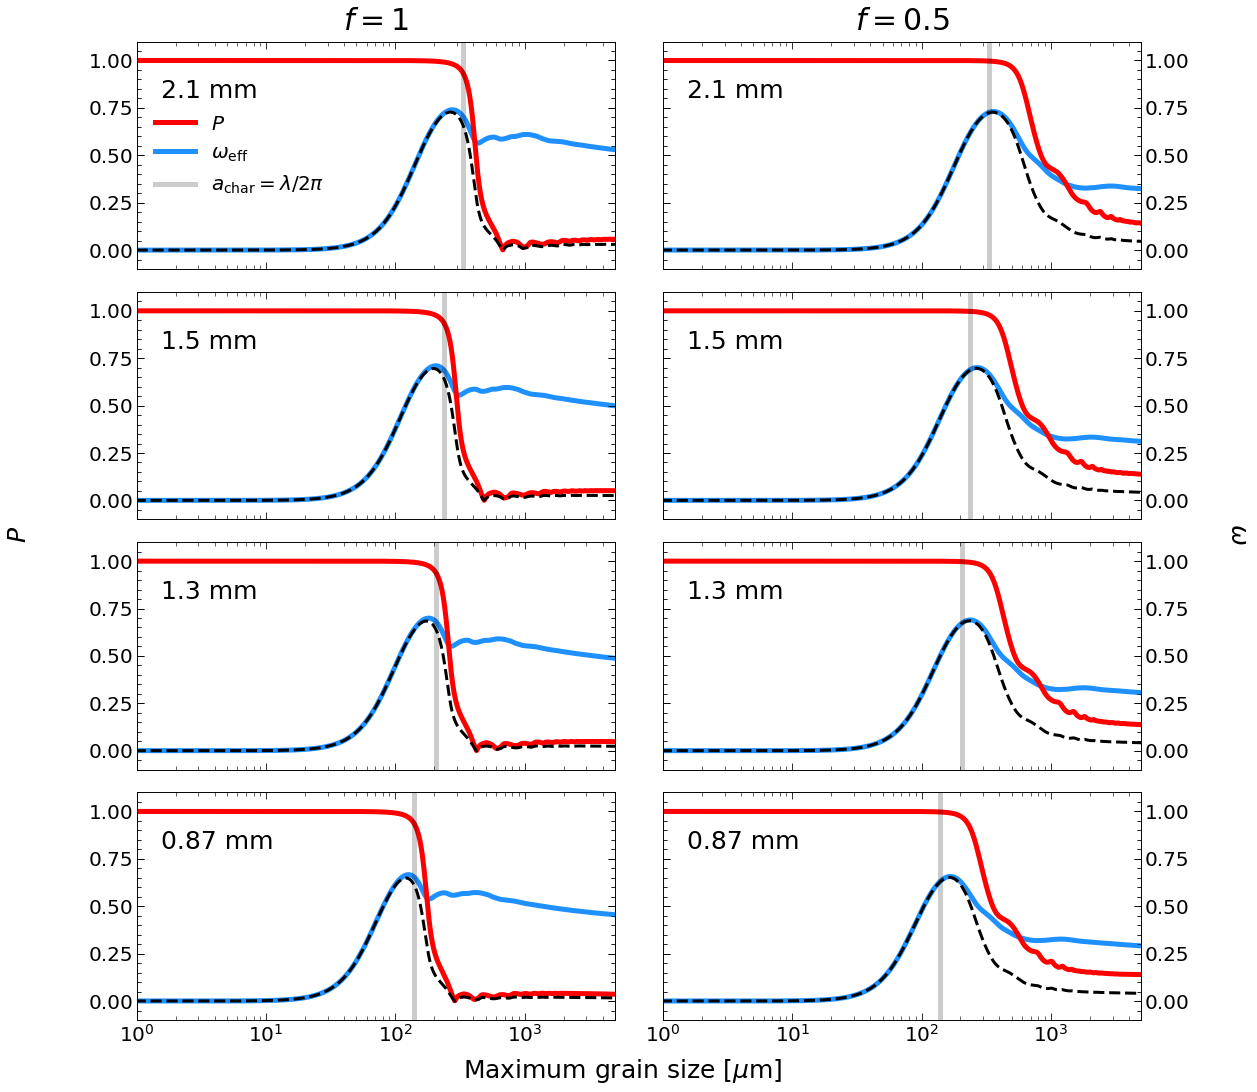

In [91]:
porosity = '1'
fig, axes = plot_P_omega_grid(data, wavelengths, albedo = 'w')

plt.savefig(writeup_image_folder_path + '/DustModels/' + "P_vs_w_vs_grainsize_grid_smooth_porosities.pdf",
            dpi=300, facecolor='white', bbox_inches='tight')